In [17]:
import numpy as np
from scipy import constants
import pandas as pd
pd.set_option('display.width', 10000) # Adjust for desired width
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None) # display full content in a column
import matplotlib.pyplot as plt
from tweezer_functions import * 
from IonChainTools import *
from scipy.optimize import fsolve
import matplotlib.colors as mcolors
import matplotlib.colorbar as mcolorbar
from scipy.optimize import fsolve
from scipy.optimize import curve_fit
from scipy.optimize import minimize
import matplotlib.ticker as ticker
import itertools
import math

#Constants in SI units
eps0 = constants.epsilon_0 
m = 39.9626*constants.atomic_mass
c = constants.c
e = constants.e
hbar = constants.hbar
pi = np.pi

# setting up parameters that we're not changing
qubit_wavelength = 729e-9
tweezer_wavelength = 532e-9
omega_tweezer = 2*pi*c/tweezer_wavelength
print(omega_tweezer)
df = pd.read_csv("S_P_only.csv",sep = ",",encoding = "UTF-8")
lambdares = np.array(df["wavelength (nm)"])*1e-9
omega_res = 2*pi*c/lambdares
linewidths = np.array(df["A_ki (s^-1)"])
lifetimes = linewidths
print(linewidths)
#test

3540698434791077.0
[1.47e+08 1.40e+08]


In [18]:
P = 100e-3
w0 = 1e-6
Intensity = 2*P/(pi*w0**2)
e_delta = (3*pi*c**2)/(2*omega_res[0]**3) * linewidths[0]/(omega_tweezer - omega_res[0]) * Intensity + (3*pi*c**2)/(2*omega_res[1]**3) * linewidths[1]/(omega_tweezer - omega_res[1]) * Intensity
print(((e_delta / hbar)/(2*pi))*1e-6,"Stark Shift in MHz")

-87.8353196847003 Stark Shift in MHz


# Parallel optimization, tweezed vs untweezed with defined functions, not optimized power

In [20]:
N_max = 6  # Change this to run for higher N values
P_opt = [50e-3]
w0 = 1e-6
f_rf_r = 3e6
f_rf_a = 125e3

# New tweezer_functions API expects equilibrium positions dictionary
ueq = {N: ion_spacing(N, pi*f_rf_a)[0] for N in range(2, N_max + 1)}


results_test_check = []
for Ni in range(2, N_max + 1):
    winners = run_optimal_mode_selection_tweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        ueq,
        P_opt,
        w0,
        max_tweezed=1,
    )
    results_test_check.append((Ni, winners))

untweezed_results = []

print(f_rf_r, f_rf_a)
for Ni in range(2, N_max + 1):
    winners = run_optimal_mode_selection_untweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        ueq,
        P_opt,
        w0,
    )
    untweezed_results.append((Ni, winners))

untweezed_winners = [untweezed_results[i - 2][1][0][2] for i in range(2, N_max + 1)]

3000000.0 125000.0


In [21]:
untweezed_winners

[0.03956930721333248,
 0.032308204049369134,
 0.02797972545743188,
 0.025025827245823196,
 0.02284535017128783]

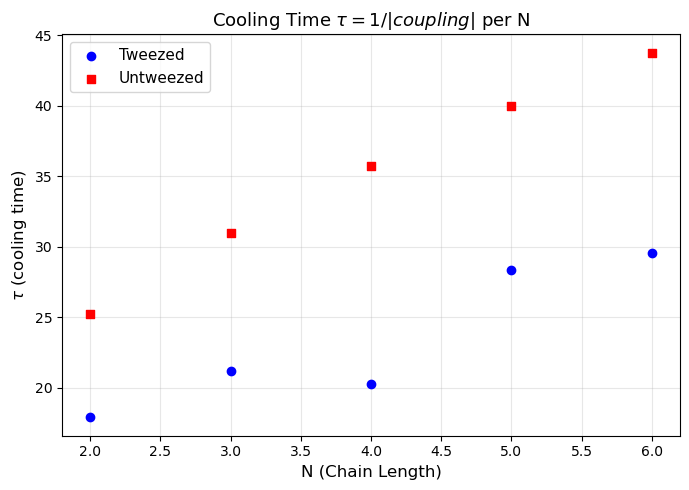

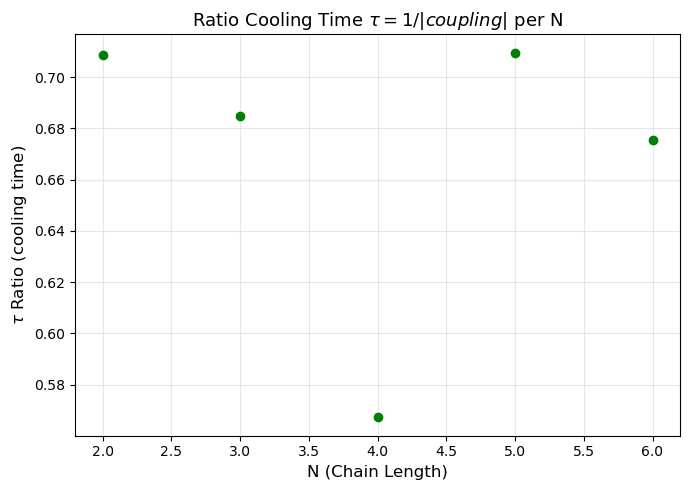

In [22]:
tweezed_data = {}  # {N: score}

for N_val, winners in results_test_check:
    if not winners:
        continue
    
    # Just take the first winner (it's already the best)
    win = winners[0]
    
    # Extract tweezed ion directly
    if isinstance(win, (list, tuple)) and isinstance(win[0], (list, tuple)):
        tweezed_ion = win[0][0]
    else:
        tweezed_ion = win[0]
    
    if tweezed_ion is None:
        continue  # Skip untweezed
    
    # Extract score directly
    if isinstance(win, (list, tuple)) and isinstance(win[0], (list, tuple)) and len(win[0]) >= 3:
        score = win[0][2]
    elif isinstance(win, (list, tuple)) and len(win) >= 3:
        score = win[2]
    else:
        score = None
    
    if score is not None:
        tweezed_data[N_val] = abs(score)

# --- Extract untweezed winning scores (same approach) ---
untweezed_data = {}  # {N: score}

for N_val, winners in untweezed_results:
    if not winners:
        continue
    
    # Just take the first winner
    win = winners[0]
    
    # Extract score directly
    if isinstance(win, (list, tuple)) and isinstance(win[0], (list, tuple)) and len(win[0]) >= 3:
        score = win[0][2]
    elif isinstance(win, (list, tuple)) and len(win) >= 3:
        score = win[2]
    else:
        score = None
    
    if score is not None:
        untweezed_data[N_val] = abs(score)

# --- Prepare arrays for plotting ---
N_tweezed = sorted(tweezed_data.keys())
scores_tweezed = [tweezed_data[N] for N in N_tweezed]

N_untweezed = sorted(untweezed_data.keys())
scores_untweezed = [untweezed_data[N] for N in N_untweezed]

# Convert to 1/score (tau) for better visibility
tau_tweezed = np.array([1.0 / s if s != 0 else np.inf for s in scores_tweezed])
tau_untweezed = np.array([1.0 / s if s != 0 else np.inf for s in scores_untweezed])

# --- Plot ---
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
# Plot : Tau (1/score) for easier interpretation
ax.scatter(N_tweezed, tau_tweezed, marker='o', color='blue', 
            label='Tweezed', zorder=3)
ax.scatter(N_untweezed, tau_untweezed, marker='s', color='red', 
            label='Untweezed', zorder=3)
ax.set_xlabel('N (Chain Length)', fontsize=12)
ax.set_ylabel(r'$\tau$ (cooling time)', fontsize=12)
ax.set_title(r'Cooling Time $\tau = 1/|coupling|$ per N', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

# --- Plot ---
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
# Plot : Tau (1/score) for easier interpretation
ax.scatter(N_tweezed, tau_tweezed/tau_untweezed, marker='o', color='green', 
            zorder=3)
ax.set_xlabel('N (Chain Length)', fontsize=12)
ax.set_ylabel(r'$\tau$ Ratio (cooling time)', fontsize=12)
ax.set_title(r'Ratio Cooling Time $\tau = 1/|coupling|$ per N', fontsize=13)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Power sweep

In [45]:
N_values = np.arange(2, 8)
w0 = 1e-6
P_list = np.linspace(1e-6, 0.25, 100)  # optical powers from 10 mW to 1 W



# --- Run power sweep using your tweezed-only function ---
power_results = [[] for _ in N_values]  # List of lists to hold winners for each N
for N in N_values:
    for P in P_list:
        winners = run_optimal_mode_selection_tweezed_only(
            omega_tweezer,
            linewidths,
            omega_res,
            m,
            mode_calc_r,
            N,
            f_rf_r,
            ueq,
            P,
            w0,
            max_tweezed=1,
        )
        power_results[N - 2].append(winners)

KeyError: 7

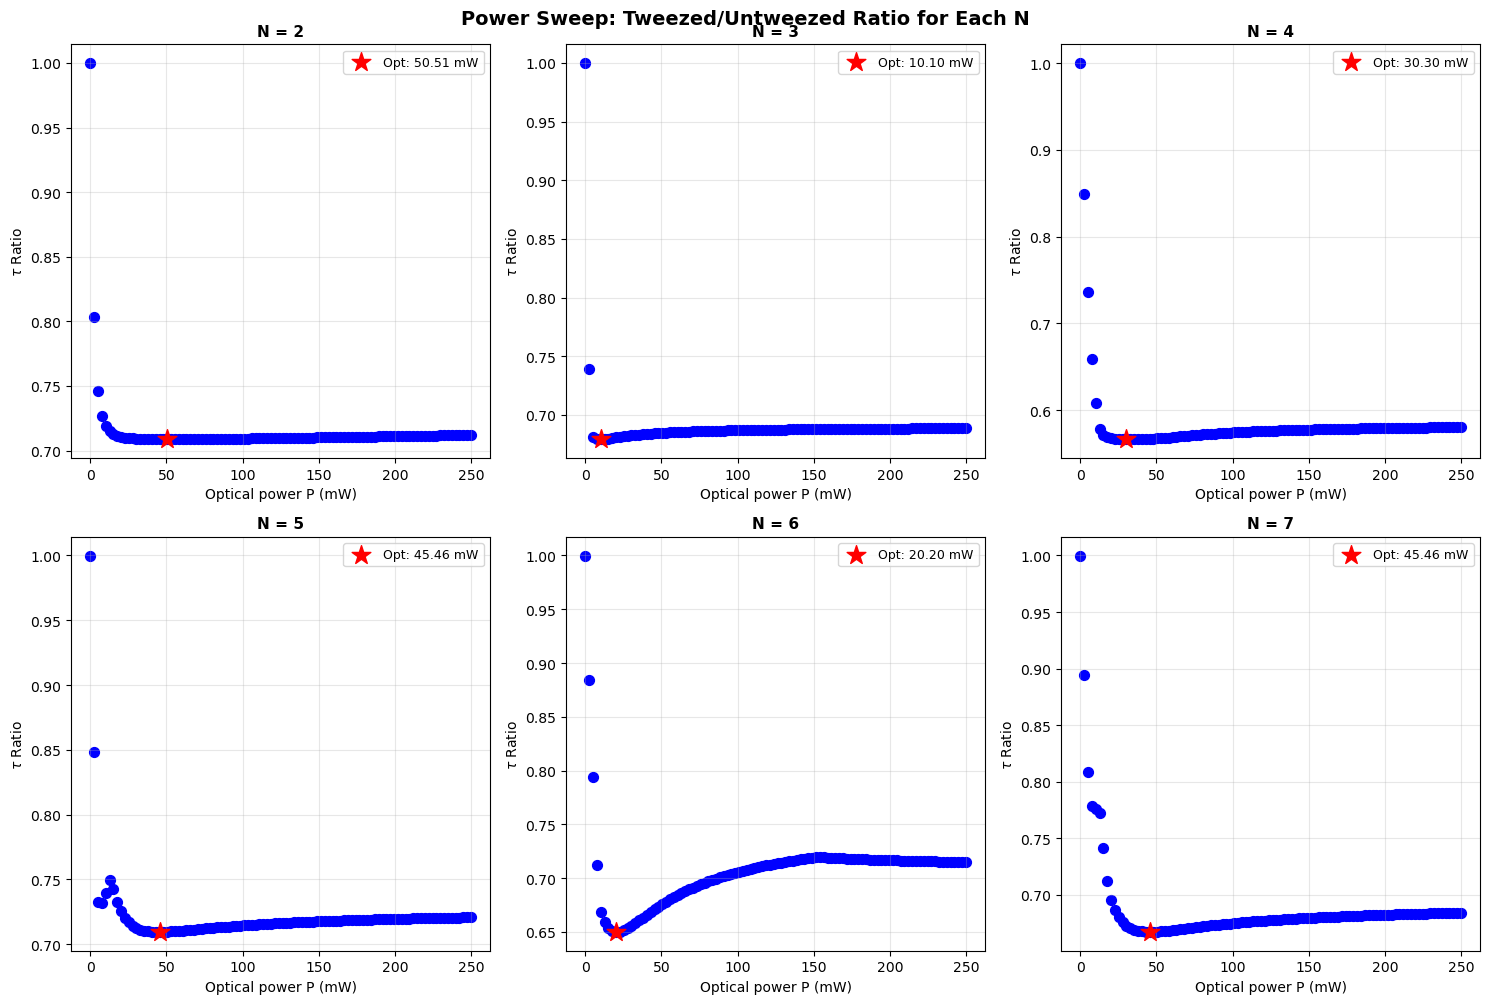


Optimal Powers Summary:
N = 2: P_opt = 5.050585e-02 W = 50.5058 mW,  Ratio = 0.7086
N = 3: P_opt = 1.010197e-02 W = 10.1020 mW,  Ratio = 0.6791
N = 4: P_opt = 3.030391e-02 W = 30.3039 mW,  Ratio = 0.5661
N = 5: P_opt = 4.545536e-02 W = 45.4554 mW,  Ratio = 0.7094
N = 6: P_opt = 2.020294e-02 W = 20.2029 mW,  Ratio = 0.6499
N = 7: P_opt = 4.545536e-02 W = 45.4554 mW,  Ratio = 0.6673


In [ ]:
# --- Extract and plot for each N ---
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Ensure ueq exists for new API
if 'ueq' not in globals():
    try:
        ueq = {N: ion_spacing(N, w_rf_a=2*pi*f_rf_a)[0] for N in range(2, 40)}
    except TypeError:
        ueq = {N: ion_spacing(N, w_rf_a=2*pi*f_rf_a)[0] for N in range(2, 40)}

optimal_powers_W = []
optimal_powers_mW = []
optimal_ratios = []

for Ni in range(2, 8):
    winners = run_optimal_mode_selection_untweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        ueq,
        P_opt,
        w0,
    )
    untweezed_results.append((Ni, winners))

untweezed_winners = [untweezed_results[i - 2][1][0][2] for i in range(2, 8)]

for idx, N in enumerate(N_values):
    x_tweezed = []
    y_tweezed = []

    # Extract scores from power_results for this N
    for P_opt, winners in zip(P_list, power_results[N - 2]):
        if not winners:
            continue
        winner = winners[0]

        if len(winner) >= 3:
            tweezed_ion = winner[0]
            score = winner[2]
        else:
            continue

        if tweezed_ion is None:
            continue

        x_tweezed.append(P_opt)
        y_tweezed.append(abs(score))

    x_tweezed = np.array(x_tweezed)
    y_tweezed = np.array(y_tweezed)

    untweezed_ref = untweezed_winners[N - 2]

    if len(y_tweezed) > 0:
        ratio = untweezed_ref / y_tweezed
        opt_idx = np.argmin(ratio)

        opt_power_W = x_tweezed[opt_idx]
        opt_power_mW = opt_power_W * 1e3
        opt_ratio = ratio[opt_idx]

        optimal_powers_W.append(opt_power_W)
        optimal_powers_mW.append(opt_power_mW)
        optimal_ratios.append(opt_ratio)

        # Plot
        axes[idx].scatter(x_tweezed * 1e3, ratio, marker='o', color='blue', s=50)
        axes[idx].set_xlabel("Optical power P (mW)", fontsize=10)
        axes[idx].set_ylabel(r"$\tau$ Ratio", fontsize=10)
        axes[idx].set_title(f"N = {N}", fontsize=11, fontweight='bold')
        axes[idx].grid(True, alpha=0.3)

        axes[idx].scatter(
            opt_power_mW,
            opt_ratio,
            color='red',
            s=200,
            marker='*',
            zorder=5,
            label=f'Opt: {opt_power_mW:.2f} mW',
        )
        axes[idx].legend(fontsize=9)

plt.tight_layout()
plt.suptitle(
    "Power Sweep: Tweezed/Untweezed Ratio for Each N",
    fontsize=14,
    fontweight='bold',
    y=1.00,
)
plt.show()

# --- Print summary (AFTER loop completes) ---
optimal_powers_W = np.array(optimal_powers_W)
optimal_powers_mW = np.array(optimal_powers_mW)
optimal_ratios = np.array(optimal_ratios)

print("\nOptimal Powers Summary:")
print("=" * 60)
for N, P_W, P_mW, ratio in zip(N_values, optimal_powers_W, optimal_powers_mW, optimal_ratios):
    print(f"N = {N}: P_opt = {P_W:.6e} W = {P_mW:.4f} mW,  Ratio = {ratio:.4f}")
print("=" * 60)

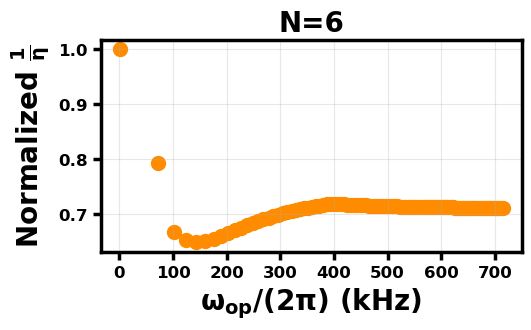


Optimal Power for N = 6:
P_opt = 2.020298e-02 W = 20.2030 mW
Ratio = 0.6499


In [43]:
# Plot power sweep for N=6 alone

N = 6
w0 = 1e-6
P_list = np.linspace(1e-6, 0.5, 100)  # optical powers

# Ensure ueq exists for new API
if 'ueq' not in globals():
    try:
        ueq = {N: ion_spacing(N, w_rf_a=2*pi*f_rf_a)[0] for N in range(2, 40)}
    except TypeError:
        ueq = {N: ion_spacing(N, w_rf_a=2*pi*f_rf_a)[0] for N in range(2, 40)}

# Run power sweep for N=6
power_results_N6 = []
tweezer_freqs_results_N6 = []
for P in P_list:
    winners = run_optimal_mode_selection_tweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        ueq,
        P,
        w0,
        max_tweezed=1,
    )
    # x axis as tweezer frequency instead:
    tweezer_freqs = omega_tweezer_r(potential(omega_tweezer, linewidths, omega_res, P, w0), w0, m)
    tweezer_freqs_results_N6.append(tweezer_freqs)

    power_results_N6.append(winners)

# Get untweezed reference for N=6
untweezed_winners_N6 = untweezed_winners[N - 2]

# Extract data
x_tweezed = []
y_tweezed = []

for P_val, winners in zip(P_list, power_results_N6):
    if not winners:
        continue
    winner = winners[0]

    if len(winner) >= 3:
        tweezed_ion = winner[0]
        score = winner[2]
    else:
        continue

    if tweezed_ion is None:
        continue

    x_tweezed.append(P_val)
    y_tweezed.append(abs(score))

x_tweezed = np.array(x_tweezed)
y_tweezed = np.array(y_tweezed)

# Calculate ratio
ratio = untweezed_winners_N6 / y_tweezed
opt_idx = np.argmin(ratio)

opt_power_W = x_tweezed[opt_idx]
opt_power_mW = opt_power_W * 1e3
opt_ratio = ratio[opt_idx]

# Plot
px = 1 / plt.rcParams["figure.dpi"]
fig, ax = plt.subplots(figsize=(520 * px, 319 * px), layout='constrained')
ax.scatter(
    np.array(tweezer_freqs_results_N6) / (2.0 * pi * 1e3),  # Convert to kHz
    ratio,
    marker='o',
    color='#FF8C00',
    s=100,
    label='Ratio across power',
)
# ax.scatter(opt_power_mW, opt_ratio, color='red', s=200, marker='*',
#            zorder=5, label=f'Optimal: P={opt_power_mW:.2f} mW, Ratio={opt_ratio:.4f}')
ax.set_xlabel("$\mathbf{\omega_{op}/(2\pi)}$ (kHz)", fontsize=20, fontweight='bold')
ax.set_ylabel(r"Normalized $\mathbf{\frac{1}{\eta}}$", fontsize=20, fontweight='bold')
ax.set_title(f"N=6", fontsize=20, fontweight='bold')
ax.set_xticks([0, 200, 400, 600])
ax.set_yticks([0.65, 0.82, 1.0])
ax.tick_params(axis='both', which='both', width=2.5, length=6, labelsize=12)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')
for spine in ax.spines.values():
    spine.set_linewidth(2.5)
ax.grid(True, alpha=0.3)
# ax.legend(fontsize=11)

plt.show()

print(f"\nOptimal Power for N = {N}:")
print("=" * 60)
print(f"P_opt = {opt_power_W:.6e} W = {opt_power_mW:.4f} mW")
print(f"Ratio = {opt_ratio:.4f}")
print("=" * 60)

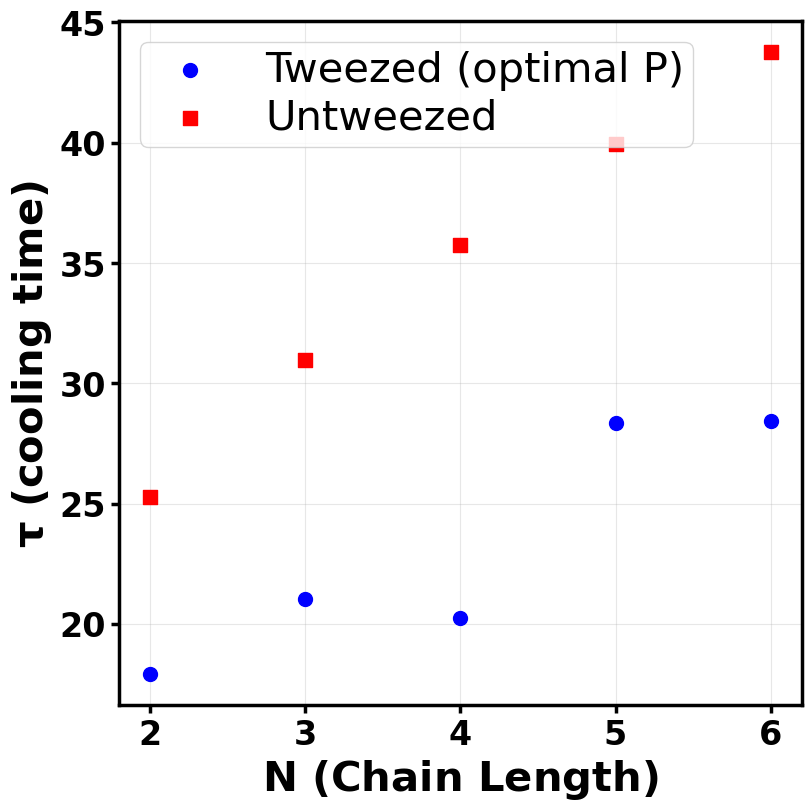

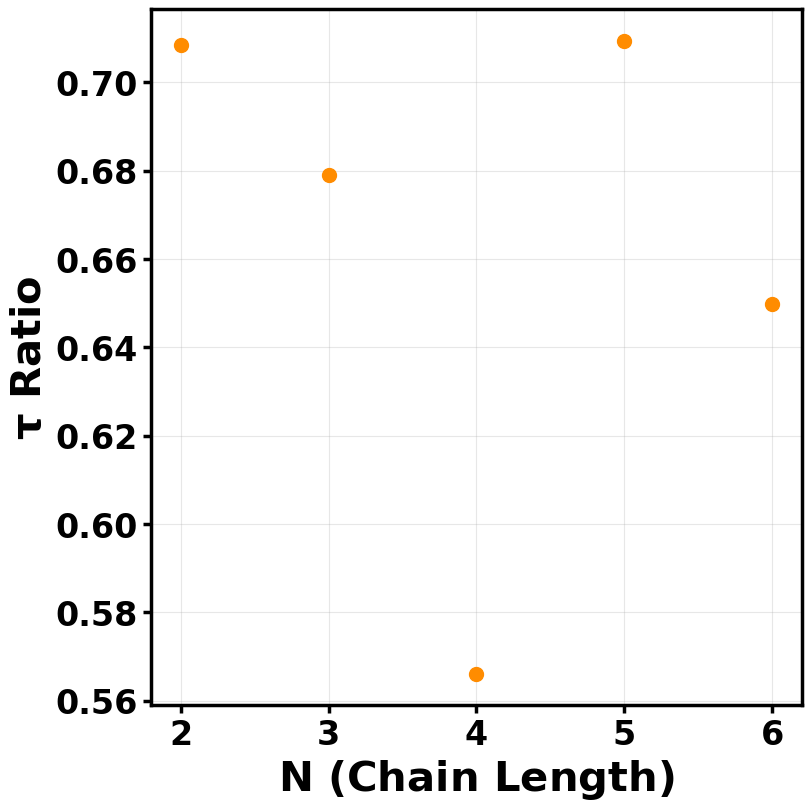

In [59]:
# --- Plot tau comparison at optimal powers from the power sweep ---
N_values_plot = list(N_values)

# Guard against partial runs (e.g. power sweep errored partway through)
n = min(len(N_values_plot), len(untweezed_winners), len(optimal_ratios))
N_values_plot = N_values_plot[:n]
uw = np.array(untweezed_winners[:n])
opt_r = np.array(optimal_ratios[:n])

tau_untweezed_opt = 1.0 / uw
tau_tweezed_opt = opt_r * tau_untweezed_opt

px = 1 / plt.rcParams['figure.dpi']

def style_ax(ax):
    ax.tick_params(axis='both', which='both', width=2.5, length=6, labelsize=24)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
    ax.grid(True, alpha=0.3)

# --- Plot 1: absolute tau values ---
fig, ax = plt.subplots(figsize=(800 * px, 800 * px), layout='constrained')
ax.scatter(N_values_plot, tau_tweezed_opt, marker='o', color='blue', s=100,
           label='Tweezed (optimal P)', zorder=3)
ax.scatter(N_values_plot, tau_untweezed_opt, marker='s', color='red', s=100,
           label='Untweezed', zorder=3)
ax.set_xlabel(r'$\mathbf{N}$ (Chain Length)', fontsize=30, fontweight='bold')
ax.set_ylabel(r'$\mathbf{\tau}$ (cooling time)', fontsize=30, fontweight='bold')
ax.legend(fontsize=30, borderpad=0.2, labelspacing=0.2)
style_ax(ax)
plt.show()

# --- Plot 2: tau ratio at optimal power ---
fig, ax = plt.subplots(figsize=(800 * px, 800 * px), layout='constrained')
ax.scatter(N_values_plot, opt_r, marker='o', color='#FF8C00', s=100, zorder=3)
ax.set_xlabel(r'$\mathbf{N}$ (Chain Length)', fontsize=30, fontweight='bold')
ax.set_ylabel(r'$\mathbf{\tau}$ Ratio', fontsize=30, fontweight='bold')
style_ax(ax)
plt.show()

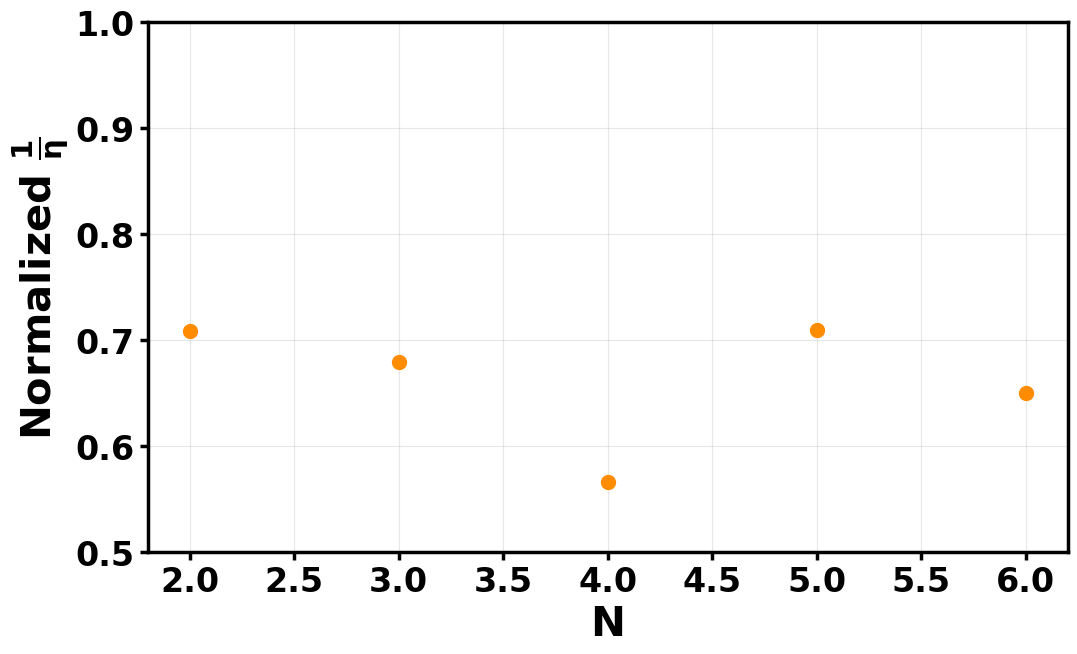

In [61]:
# --- Plot 2: tau ratio at optimal power ---
px = 1 / plt.rcParams['figure.dpi']
fig, ax = plt.subplots(figsize=(1066 * px, 643 * px), layout='constrained')
ax.scatter(N_values_plot, opt_r, marker='o', color='#FF8C00', s=100, zorder=3)
ax.set_xlabel('N', fontsize=30, fontweight='bold')
ax.set_ylabel(r'Normalized $\mathbf{\frac{1}{\eta}}$', fontsize=30, fontweight='bold')
ax.set_ylim(0.5, 1)
style_ax(ax)
plt.show()

In [25]:
# Show tweezed winner for N=6 at the optimal power found earlier
N = 6
P_opt_N6 = float(optimal_powers_W[N - 2])

# Ensure ueq exists for new API
if 'ueq' not in globals():
    try:
        ueq = {N: ion_spacing(N, w_rf_a=2*pi*f_rf_a)[0] for N in range(2, 40)}
    except TypeError:
        ueq = {N: ion_spacing(N, w_rf_a=2*pi*f_rf_a)[0] for N in range(2, 40)}

winners_N6_tweezed = run_optimal_mode_selection_tweezed_only(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    ueq,
    P_opt_N6,
    w0,
    max_tweezed=1,
)

if winners_N6_tweezed:
    best_tweezed = winners_N6_tweezed[0]
    print("N =", N, "P_opt (W) =", P_opt_N6)
    print("Tweezed winner (best):", best_tweezed)
else:
    print("No tweezed winner returned for N =", N, "at P =", P_opt_N6)

N = 6 P_opt (W) = 0.020202939393939395
Tweezed winner (best): (2, (2, 5, 0, 4, 1, 3), 0.03515274750797216, 0.020202939393939395, array([ 0.04570456,  0.04314636,  0.04782096,  0.03515275, -0.04745411,
       -0.04382219]))


In [26]:
# Show untweezed winner for N=6 at the optimal power found earlier
N = 6
P_opt_N6 = float(optimal_powers_W[N - 2])

# Ensure ueq exists for new API
if 'ueq' not in globals():
    try:
        ueq = {N: ion_spacing(N, w_rf_a=2*pi*f_rf_a)[0] for N in range(2, 40)}
    except TypeError:
        ueq = {N: ion_spacing(N, w_rf_a=2*pi*f_rf_a)[0] for N in range(2, 40)}

winners_N6_untweezed = run_optimal_mode_selection_untweezed_only(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    ueq,
    P_opt_N6,
    w0,
)

if winners_N6_untweezed:
    best_untweezed = winners_N6_untweezed[0]
    print("N =", N, "P_opt (W) =", P_opt_N6)
    print("Untweezed winner (best):", best_untweezed)
else:
    print("No untweezed winner returned for N =", N, "at P =", P_opt_N6)

N = 6 P_opt (W) = 0.020202939393939395
Untweezed winner (best): (nan, (0, 5, 2, 1, 4, 3), 0.02284535017128783, 0.020202939393939395, array([ 0.02284535,  0.03402723, -0.02350233,  0.03040264,  0.03145738,
       -0.03588009]))


Top vals (tweezed): [ 0.04570456  0.04314636  0.04782096  0.03515275 -0.04745411 -0.04382219]
Bottom vals (untweezed): [ 0.02284535  0.03402723 -0.02350233  0.03040264  0.03145738 -0.03588009]


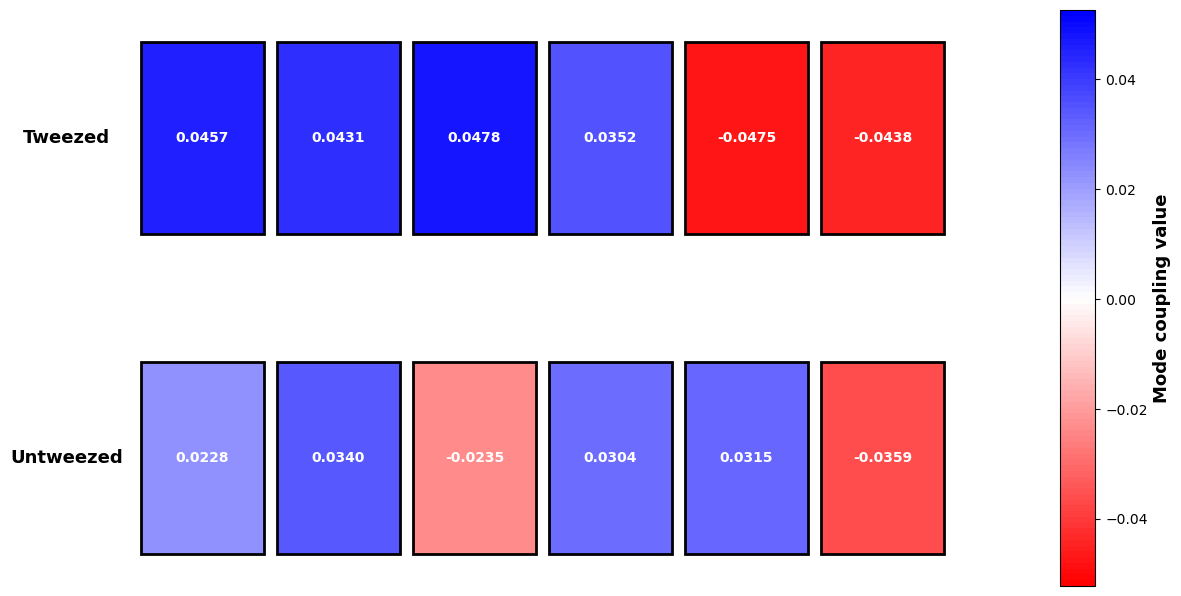

In [27]:
# Stack tweezed (top) and untweezed (bottom) winner visualizations with shared color scale

N = 6
P_opt_N6 = float(optimal_powers_W[N - 2])

# Ensure ueq exists for new API
if 'ueq' not in globals():
    try:
        ueq = {N: ion_spacing(N, w_rf_a=2*pi*f_rf_a)[0] for N in range(2, 40)}
    except TypeError:
        ueq = {N: ion_spacing(N, w_rf_a=2*pi*f_rf_a)[0] for N in range(2, 40)}

# ---------- Top: tweezed ----------
if 'winners_N6_tweezed' not in globals() or not winners_N6_tweezed:
    winners_N6_tweezed = run_optimal_mode_selection_tweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        ueq,
        P_opt_N6,
        w0,
        max_tweezed=1,
    )

if not winners_N6_tweezed:
    raise ValueError("No tweezed winner returned for N=6.")

vals_top = np.array(winners_N6_tweezed[0][4], dtype=float)
print("Top vals (tweezed):", vals_top)

# ---------- Bottom: untweezed ----------
if 'winners_N6_untweezed' not in globals() or not winners_N6_untweezed:
    winners_N6_untweezed = run_optimal_mode_selection_untweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        ueq,
        P_opt_N6,
        w0,
    )

if not winners_N6_untweezed:
    raise ValueError("No untweezed winner returned for N=6.")

vals_bottom = np.array(winners_N6_untweezed[0][4], dtype=float)
print("Bottom vals (untweezed):", vals_bottom)

# Create diverging colormap
colors_div = ['red', 'white', 'blue']
n_bins = 100
cmap_div = mcolors.LinearSegmentedColormap.from_list('red_white_blue', colors_div, N=n_bins)

# Shared normalization using +110%*max and -110%*min across BOTH sets
all_vals = np.concatenate([vals_top, vals_bottom])
vmax = 1.1 * np.max(all_vals)
vmin = 1.1 * np.min(all_vals)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# --- Single figure: rectangles + vertical colorbar on the right ---
fig = plt.figure(figsize=(14, 8))

rect_width = 0.9
rect_height = 1.5
y_pos = 0.25

# --- Top rectangles (Tweezed) ---
n_top = len(vals_top)
ax_top = fig.add_axes([0.20, 0.54, 0.68, 0.32])
ax_top.set_xlim(-0.5, n_top + 0.5)
ax_top.set_ylim(0, 2)
ax_top.axis('off')

fig.text(0.2, 0.70, 'Tweezed', ha='center', va='center', fontsize=13, fontweight='bold')

for i, val in enumerate(vals_top):
    x_pos = i + 0.05
    color = cmap_div(norm(val))
    rect = plt.Rectangle((x_pos, y_pos), rect_width, rect_height, facecolor=color, edgecolor='black', linewidth=2)
    ax_top.add_patch(rect)
    text_color = 'white' if abs(val) > 0.35 * max(abs(vmin), abs(vmax)) else 'black'
    ax_top.text(
        x_pos + rect_width / 2,
        y_pos + rect_height / 2,
        f'{val:.4f}',
        ha='center',
        va='center',
        fontsize=10,
        fontweight='bold',
        color=text_color,
    )

# --- Bottom rectangles (Untweezed) ---
n_bottom = len(vals_bottom)
ax_bottom = fig.add_axes([0.20, 0.14, 0.68, 0.32])
ax_bottom.set_xlim(-0.5, n_bottom + 0.5)
ax_bottom.set_ylim(0, 2)
ax_bottom.axis('off')

fig.text(0.2, 0.30, 'Untweezed', ha='center', va='center', fontsize=13, fontweight='bold')

for i, val in enumerate(vals_bottom):
    x_pos = i + 0.05
    color = cmap_div(norm(val))
    rect = plt.Rectangle((x_pos, y_pos), rect_width, rect_height, facecolor=color, edgecolor='black', linewidth=2)
    ax_bottom.add_patch(rect)
    text_color = 'white' if abs(val) > 0.35 * max(abs(vmin), abs(vmax)) else 'black'
    ax_bottom.text(
        x_pos + rect_width / 2,
        y_pos + rect_height / 2,
        f'{val:.4f}',
        ha='center',
        va='center',
        fontsize=10,
        fontweight='bold',
        color=text_color,
    )

# --- Vertical colorbar on the right, spanning both rows ---
cax = fig.add_axes([0.91, 0.14, 0.025, 0.72])
cb = mcolorbar.ColorbarBase(
    cax,
    cmap=cmap_div,
    norm=norm,
    orientation='vertical',
)
cb.set_label('Mode coupling value', fontsize=13, fontweight='bold')

plt.show()


Using untweezed vals from winner: [ 0.02284535  0.03402723 -0.02350233  0.03040264  0.03145738 -0.03588009]


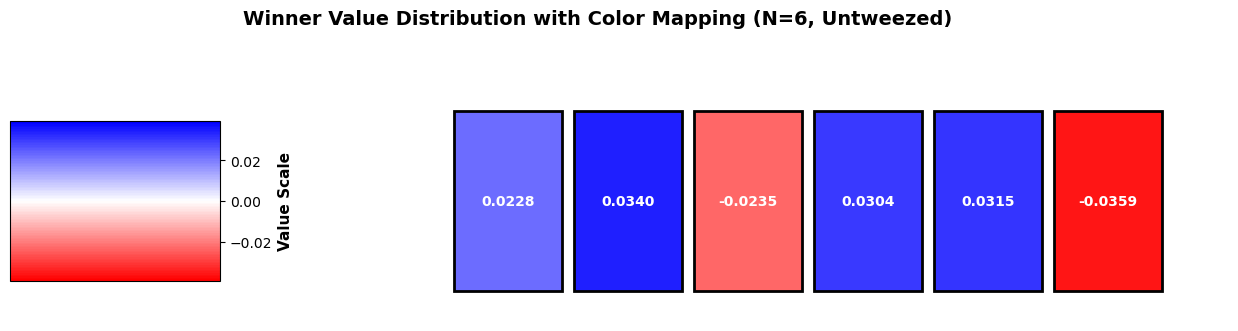

In [28]:
# Create colorbar and colored rectangles using the ACTUAL untweezed winner values for N=6

# Reuse untweezed winner from previous cell if available; otherwise compute it
if 'winners_N6_untweezed' not in globals() or not winners_N6_untweezed:
    N = 6
    P_opt_N6 = float(optimal_powers_W[N - 2])
    if 'ueq' not in globals():
        try:
            ueq = {N: ion_spacing(N, w_rf_a=2*pi*f_rf_a)[0] for N in range(2, 40)}
        except TypeError:
            ueq = {N: ion_spacing(N, w_rf_a=2*pi*f_rf_a)[0] for N in range(2, 40)}

    winners_N6_untweezed = run_optimal_mode_selection_untweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        ueq,
        P_opt_N6,
        w0,
    )

if not winners_N6_untweezed:
    raise ValueError("No untweezed winner returned for N=6, cannot build value rectangles.")

best = winners_N6_untweezed[0]

# New API returns (tweezed_ion, mapping, score, P_opt, full_lamb_dicke_vector)
vals = np.array(best[4], dtype=float)
print("Using untweezed vals from winner:", vals)

# Create a diverging colormap: red (-) -> white (0) -> blue (+)
colors_div = ['red', 'white', 'blue']
n_bins = 100
cmap_div = mcolors.LinearSegmentedColormap.from_list('red_white_blue', colors_div, N=n_bins)

# Data-driven symmetric normalization (with small headroom)
abs_max = np.max(np.abs(vals)) if vals.size else 1.0
norm = mcolors.Normalize(vmin=-1.1 * abs_max, vmax=1.1 * abs_max)

fig = plt.figure(figsize=(14, 4))

# --- Create colorbar on the left ---
cax_colorbar = fig.add_axes([0.08, 0.3, 0.15, 0.4])
cb = mcolorbar.ColorbarBase(
    cax_colorbar,
    cmap=cmap_div,
    norm=norm,
    orientation='vertical',
)
cb.set_label("Value Scale", fontsize=11, fontweight='bold')

# --- Create rectangles with values ---
n_vals = len(vals)
ax_rects = fig.add_axes([0.35, 0.2, 0.6, 0.6])
ax_rects.set_xlim(-0.5, n_vals + 0.5)
ax_rects.set_ylim(0, 2)
ax_rects.axis('off')

# Draw rectangles
rect_width = 0.9
rect_height = 1.5
y_pos = 0.25

for i, val in enumerate(vals):
    x_pos = i + 0.05

    # Get color from the colormap
    color = cmap_div(norm(val))

    # Draw rectangle
    rect = plt.Rectangle(
        (x_pos, y_pos),
        rect_width,
        rect_height,
        facecolor=color,
        edgecolor='black',
        linewidth=2,
    )
    ax_rects.add_patch(rect)

    # Determine text color for contrast
    text_color = 'white' if abs(val) > (0.35 * abs_max) else 'black'

    # Add text in the center of rectangle
    ax_rects.text(
        x_pos + rect_width / 2,
        y_pos + rect_height / 2,
        f'{val:.4f}',
        ha='center',
        va='center',
        fontsize=10,
        fontweight='bold',
        color=text_color,
    )

plt.suptitle('Winner Value Distribution with Color Mapping (N=6, Untweezed)', fontsize=14, fontweight='bold', y=0.98)
plt.show()

# Fig 3 but with optimal powers

In [44]:
P_opt = optimal_powers_W
w0 = 1e-6
f_rf_r = 3e6
f_rf_a = 125e3

# New tweezer_functions API expects equilibrium positions dictionary
try:
    ueq = {N: ion_spacing(N, w_rf_a=2*pi*f_rf_a)[0] for N in range(2, 40)}
except TypeError:
    ueq = {N: ion_spacing(N, w_rf_a=2*pi*f_rf_a)[0] for N in range(2, 40)}

results_test_check = []
for Ni in range(2, 8):
    winners = run_optimal_mode_selection_tweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        ueq,
        P_opt,
        w0,
        max_tweezed=1,
    )
    results_test_check.append((Ni, winners))

untweezed_results = []
# First 5: 1e6 and /3, last 2: 2e6 and /5

print(f_rf_r, f_rf_a)
for Ni in range(2, 8):
    winners = run_optimal_mode_selection_untweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        ueq,
        P_opt,
        w0,
    )
    untweezed_results.append((Ni, winners))

untweezed_winners = [untweezed_results[i - 2][1][0][2] for i in range(2, 8)]

TypeError: ion_spacing() got an unexpected keyword argument 'w_rf_a'

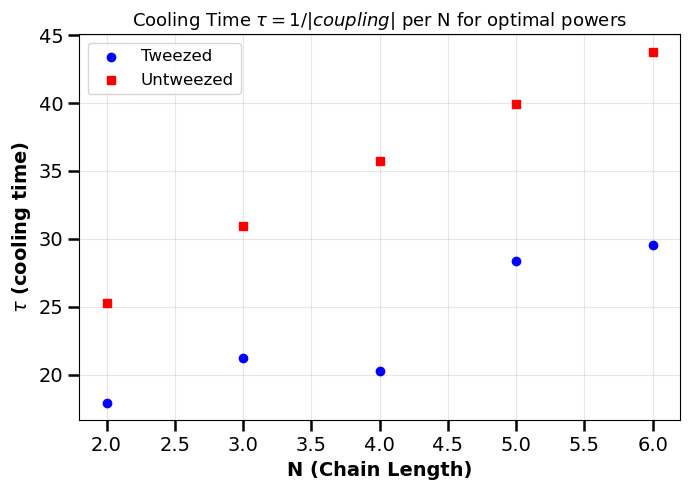

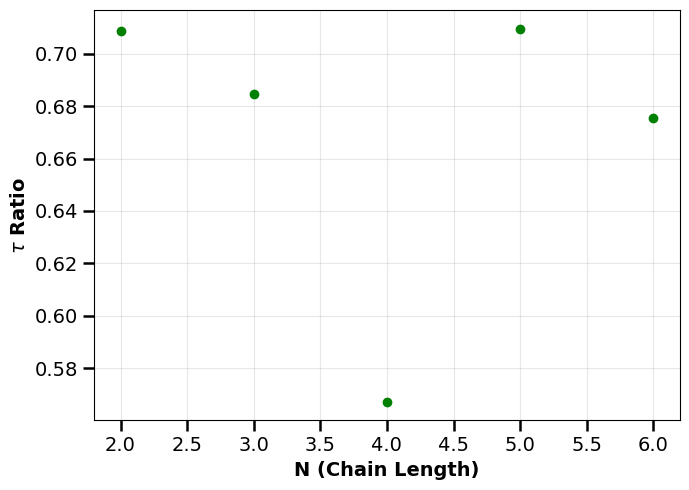

In [30]:
tweezed_data = {}  # {N: score}

for N_val, winners in results_test_check:
    if not winners:
        continue
    
    # Just take the first winner (it's already the best)
    win = winners[0]
    
    # Extract tweezed ion directly
    if isinstance(win, (list, tuple)) and isinstance(win[0], (list, tuple)):
        tweezed_ion = win[0][0]
    else:
        tweezed_ion = win[0]
    
    if tweezed_ion is None:
        continue  # Skip untweezed
    
    # Extract score directly
    if isinstance(win, (list, tuple)) and isinstance(win[0], (list, tuple)) and len(win[0]) >= 3:
        score = win[0][2]
    elif isinstance(win, (list, tuple)) and len(win) >= 3:
        score = win[2]
    else:
        score = None
    
    if score is not None:
        tweezed_data[N_val] = abs(score)

# --- Extract untweezed winning scores (same approach) ---
untweezed_data = {}  # {N: score}

for N_val, winners in untweezed_results:
    if not winners:
        continue
    
    # Just take the first winner
    win = winners[0]
    
    # Extract score directly
    if isinstance(win, (list, tuple)) and isinstance(win[0], (list, tuple)) and len(win[0]) >= 3:
        score = win[0][2]
    elif isinstance(win, (list, tuple)) and len(win) >= 3:
        score = win[2]
    else:
        score = None
    
    if score is not None:
        untweezed_data[N_val] = abs(score)

# --- Prepare arrays for plotting ---
N_tweezed = sorted(tweezed_data.keys())
scores_tweezed = [tweezed_data[N] for N in N_tweezed]

N_untweezed = sorted(untweezed_data.keys())
scores_untweezed = [untweezed_data[N] for N in N_untweezed]

# Convert to 1/score (tau) for better visibility
tau_tweezed = np.array([1.0 / s if s != 0 else np.inf for s in scores_tweezed])
tau_untweezed = np.array([1.0 / s if s != 0 else np.inf for s in scores_untweezed])

# --- Plot ---
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
# Plot : Tau (1/score) for easier interpretation
ax.scatter(N_tweezed, tau_tweezed, marker='o', color='blue', 
            label='Tweezed', zorder=3)
ax.scatter(N_untweezed, tau_untweezed, marker='s', color='red', 
            label='Untweezed', zorder=3)
ax.set_xlabel('N (Chain Length)', fontsize=14, fontweight='bold')
ax.set_ylabel(r'$\tau$ (cooling time)', fontsize=14, fontweight='bold')
ax.set_title(r'Cooling Time $\tau = 1/|coupling|$ per N for optimal powers', fontsize=13)
ax.tick_params(axis='both', which='major', labelsize=14, length=8, width=1.8)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

# --- Plot ---
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
# Plot : Tau (1/score) for easier interpretation
ax.scatter(N_tweezed, tau_tweezed/tau_untweezed, marker='o', color='green', 
            zorder=3)
ax.set_xlabel('N (Chain Length)', fontsize=14, fontweight='bold')
ax.set_ylabel(r'$\tau$ Ratio', fontsize=14, fontweight='bold')
#ax.set_title(r'Ratio Cooling Time $\tau = 1/|coupling|$ per N', fontsize=13)
ax.tick_params(axis='both', which='major', labelsize=14, length=8, width=1.8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()